## Sesión 43: Análisis Exploratorio de Datos: Tendencia y Dispersión

#### **Objetivo**: Realizar análisis descriptivos sobre 3 datasets diferentes calculando medidas de tendencia central y dispersión.


---

- DATASET 1: TITANIC
Dimensiones: (891, 15)

Primeras filas:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

- COLUMNAS ANALIZADAS: 'age' (edad) y 'fare' (tarifa)
----------------------------------------

- ESTADÍSTICAS PARA 'age' (Edad):
---------------------------

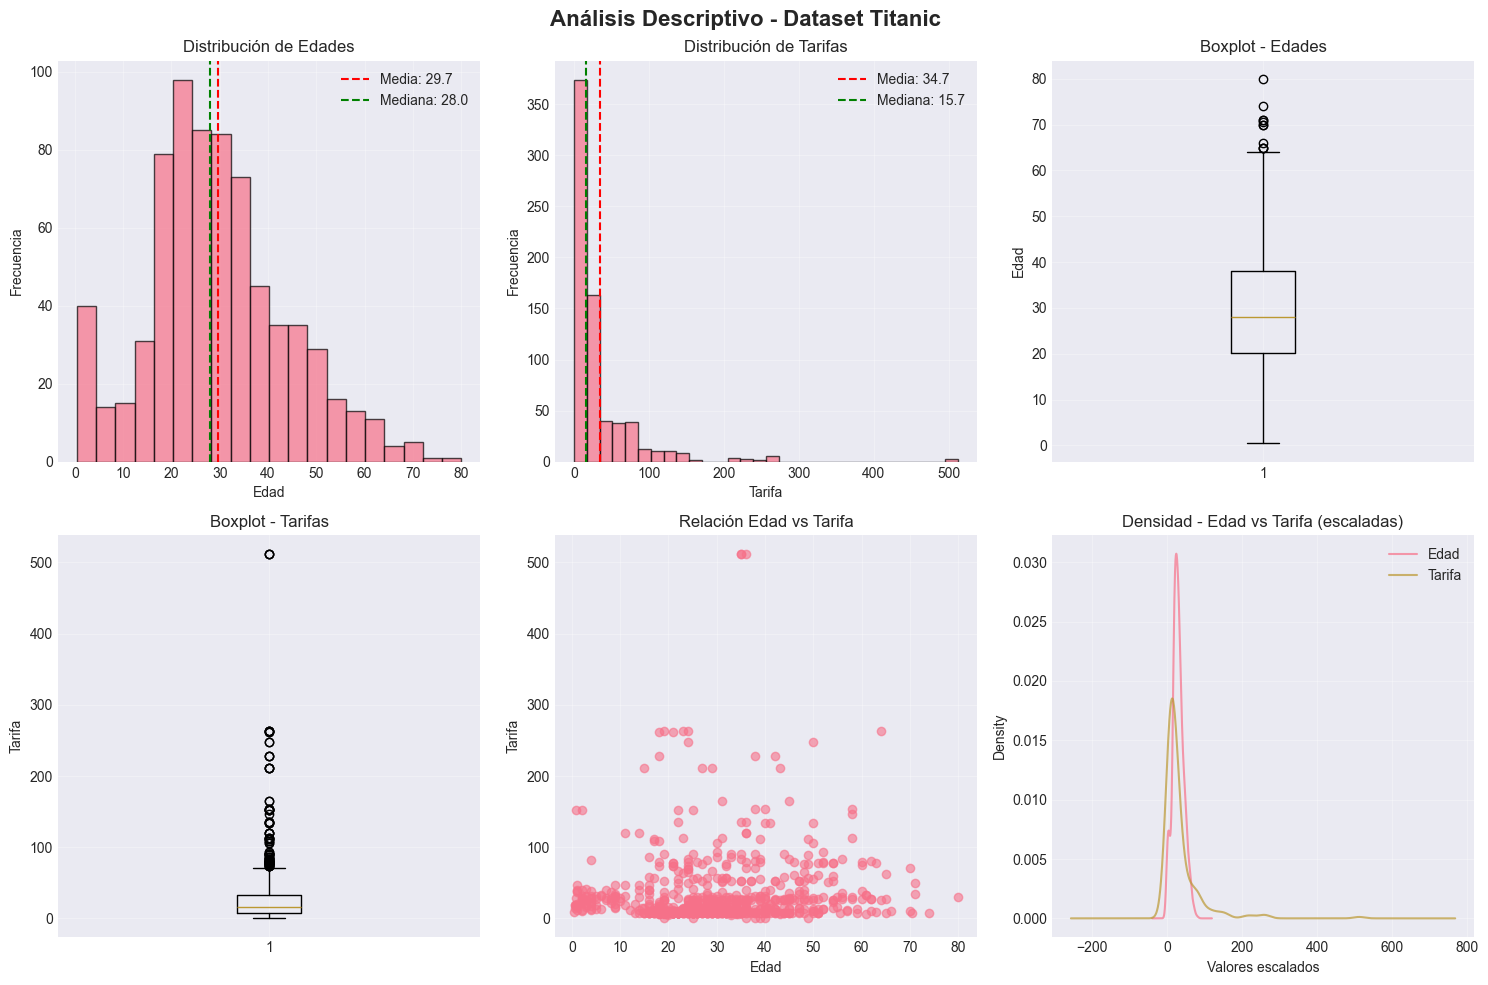



- DATASET 2: IRIS
Dimensiones: (150, 5)

Primeras filas:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

- COLUMNAS ANALIZADAS: 'sepal_length' y 'petal_length'
----------------------------------------

🔹 ESTADÍSTICAS PARA 'sepal_length' (Longitud del sépalo):
------------------------------
Media: 5.84
Mediana: 5.80
Moda: 5.00
Varianza: 0.69
Desviación Estándar: 0.83
Rango: 3.60
Mínimo: 4.30
Máximo: 7.90

- ESTADÍSTICAS PARA 'petal_length' (Longitud del pétalo):
------------------------------
Media: 3.76
Mediana: 4.35
Moda: 1.40
Varianza: 3.12
Desviación Estándar: 1.77
Rango: 5.90
Mínimo: 1.00
Máximo: 6.90


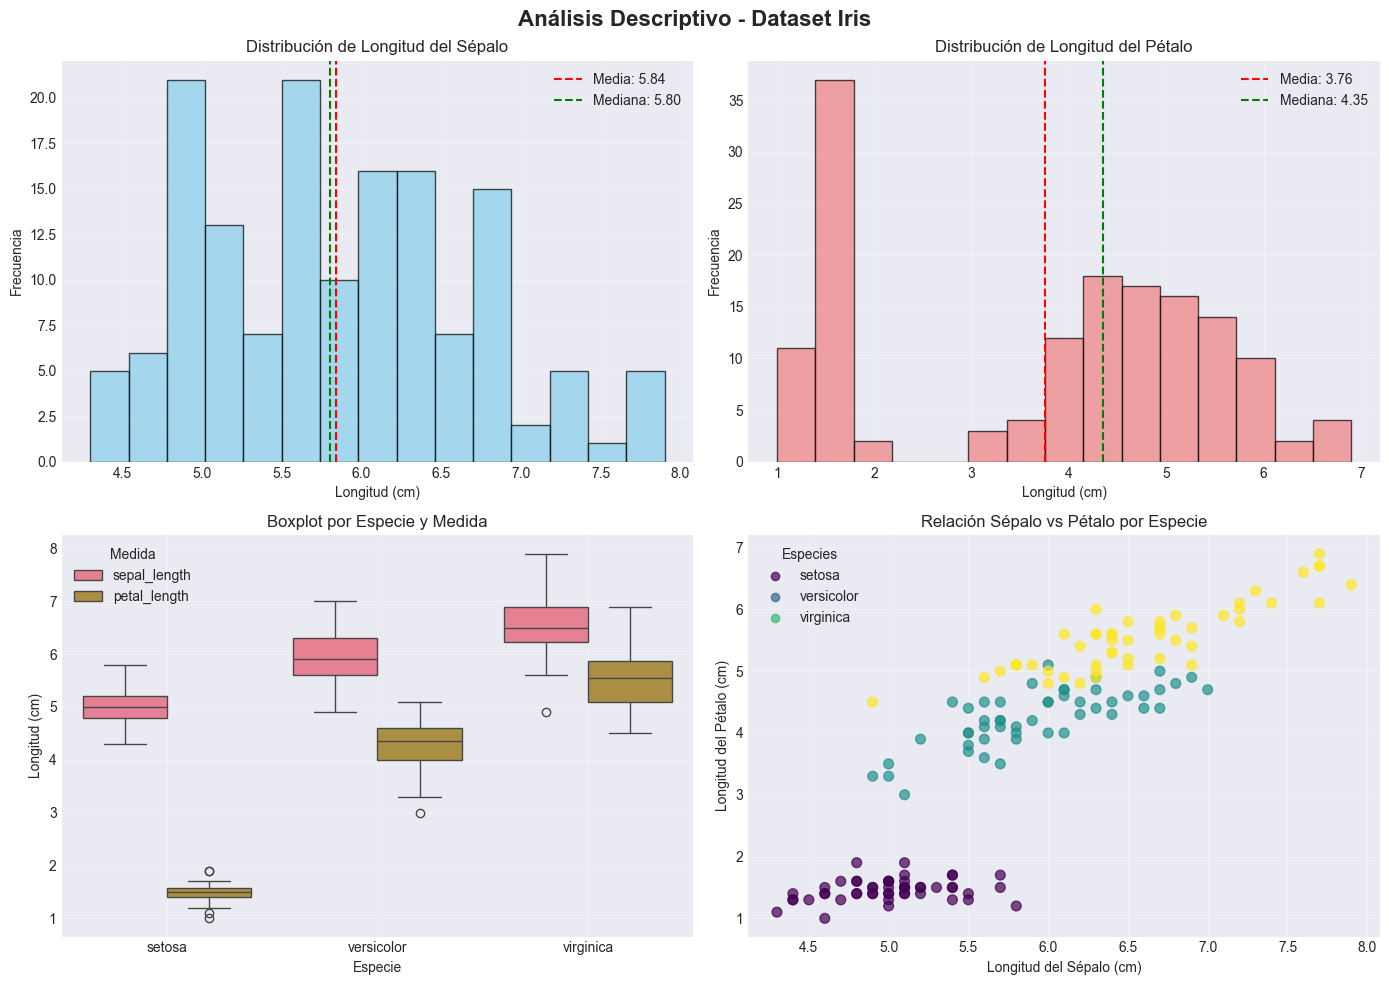



- DATASET 3: TIPS
Dimensiones: (244, 7)

Primeras filas:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

- COLUMNAS ANALIZADAS: 'total_bill' (cuenta total) y 'tip' (propina)
----------------------------------------

- ESTADÍSTICAS PARA 'total_bill' (Cuenta total):
------------------------------
Media: 19.79
Mediana: 17.80
Moda: 13.42
Varianza: 79.25
Desviación Estándar: 8.90
Rango: 47.74
Mínimo: 3.07
Máximo: 50.81

- ESTADÍSTICAS PARA 'tip' (Propina):
------------------------------
Media: 3.00
Mediana: 2.90
Moda: 2.00
Varianza: 1.91
Desviación Estándar: 1.38
Rango: 9.00
Mínimo: 1.00
Máximo: 10.00

- ESTADÍSTICAS PARA 'tip_percentage' (% de propina):
------------------------------
Media: 16.08%
Mediana: 15.48%
De

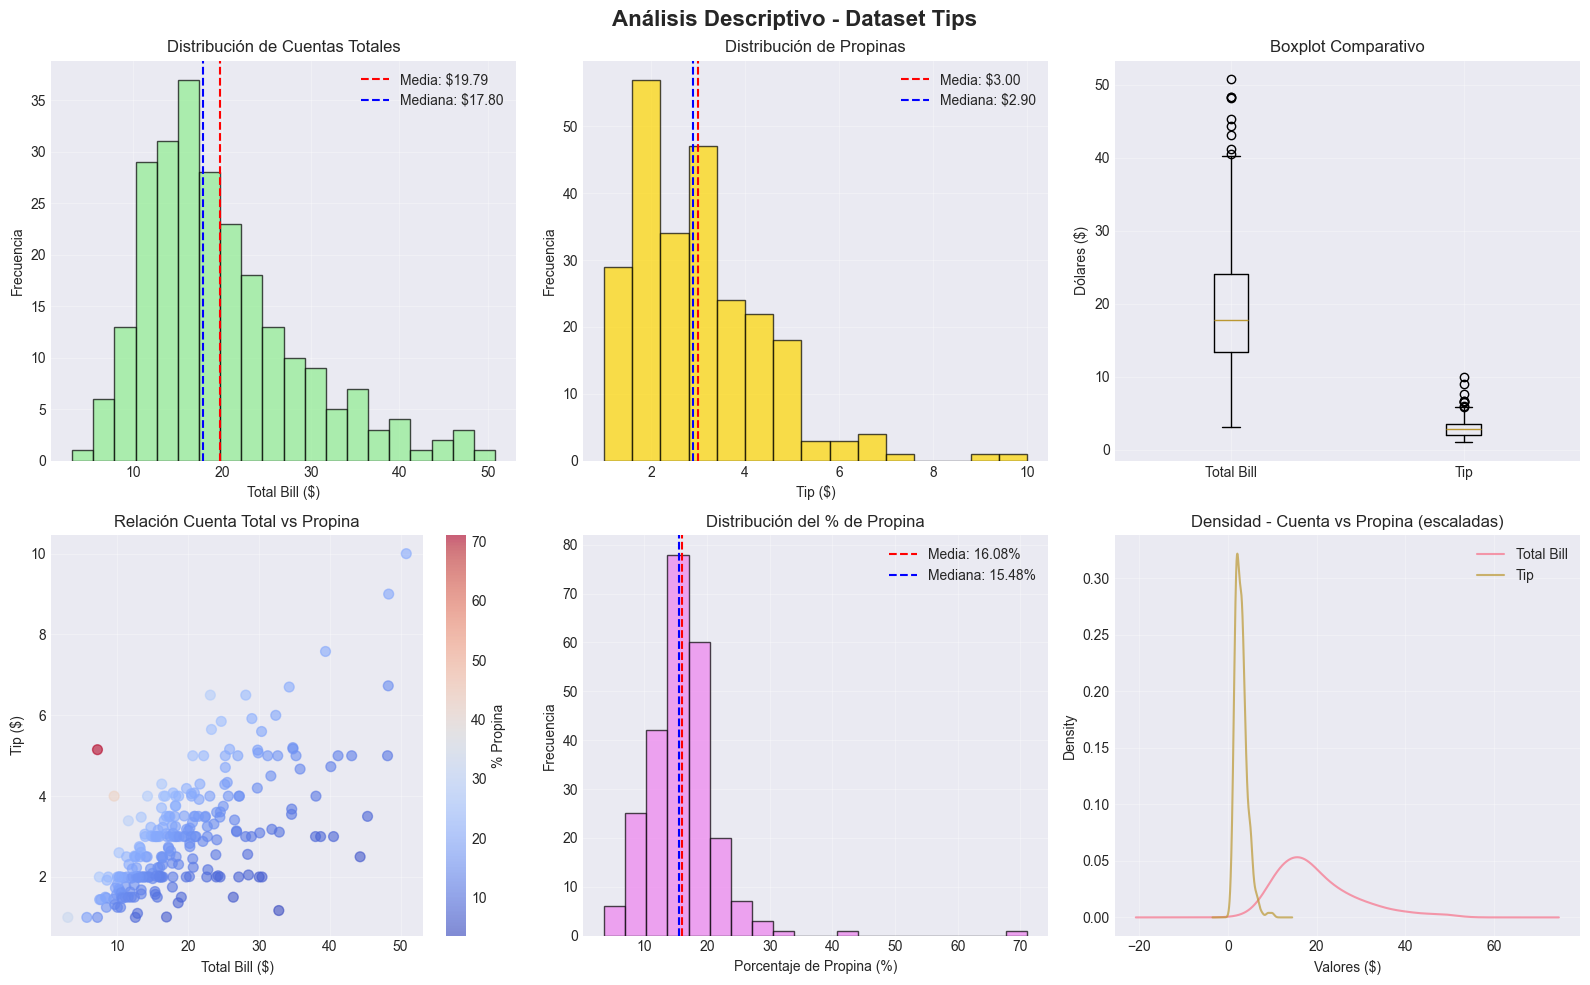

- RESUMEN COMPARATIVO - COEFICIENTES DE VARIACIÓN

Dataset Variable     Media  Desv. Estándar  CV (%)
Titanic     Edad 29.699118       14.526497   48.91
Titanic   Tarifa 34.694514       52.918930  152.53
   Iris   Sépalo  5.843333        0.828066   14.17
   Iris   Pétalo  3.758000        1.765298   46.97
   Tips   Cuenta 19.785943        8.902412   44.99
   Tips  Propina  2.998279        1.383638   46.15


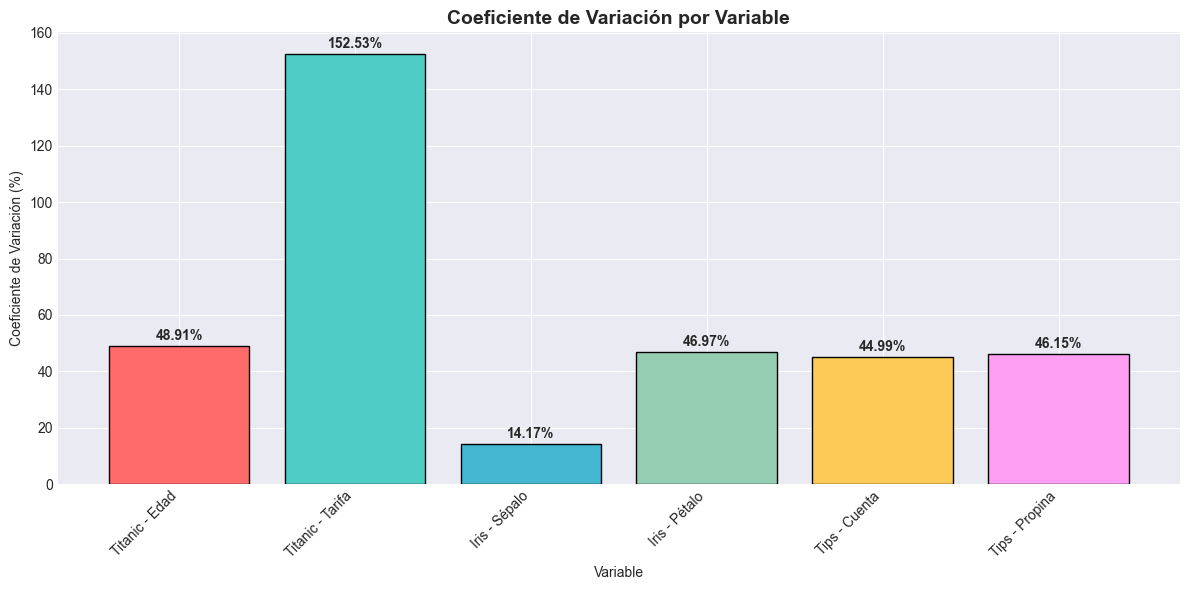

In [3]:
# 1. Configuración inicial
# Importamos las librerías necesarias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Mostrar todas las columnas en los DataFrames
pd.set_option('display.max_columns', None)

# %% [markdown]
# ## 2. Primer Dataset: Titanic

# %%
# Cargar dataset Titanic
print("- DATASET 1: TITANIC")
print("=" * 50)
titanic = sns.load_dataset('titanic')
print(f"Dimensiones: {titanic.shape}")
print(f"\nPrimeras filas:")
print(titanic.head())

# %%
# Seleccionar columnas numéricas para análisis
titanic_numeric = titanic[['age', 'fare']].copy()
titanic_numeric = titanic_numeric.dropna()

print("\n- COLUMNAS ANALIZADAS: 'age' (edad) y 'fare' (tarifa)")
print("-" * 40)

# Calcular medidas para 'age'
age_metrics = {
    'Media': titanic_numeric['age'].mean(),
    'Mediana': titanic_numeric['age'].median(),
    'Moda': titanic_numeric['age'].mode()[0],
    'Varianza': titanic_numeric['age'].var(),
    'Desviación Estándar': titanic_numeric['age'].std(),
    'Rango': titanic_numeric['age'].max() - titanic_numeric['age'].min(),
    'Mínimo': titanic_numeric['age'].min(),
    'Máximo': titanic_numeric['age'].max()
}

print("\n- ESTADÍSTICAS PARA 'age' (Edad):")
print("-" * 30)
for key, value in age_metrics.items():
    print(f"{key}: {value:.2f}")

# Calcular medidas para 'fare'
fare_metrics = {
    'Media': titanic_numeric['fare'].mean(),
    'Mediana': titanic_numeric['fare'].median(),
    'Moda': titanic_numeric['fare'].mode()[0],
    'Varianza': titanic_numeric['fare'].var(),
    'Desviación Estándar': titanic_numeric['fare'].std(),
    'Rango': titanic_numeric['fare'].max() - titanic_numeric['fare'].min(),
    'Mínimo': titanic_numeric['fare'].min(),
    'Máximo': titanic_numeric['fare'].max()
}

print("\n- ESTADÍSTICAS PARA 'fare' (Tarifa):")
print("-" * 30)
for key, value in fare_metrics.items():
    print(f"{key}: {value:.2f}")

# %%
# Visualizaciones para Titanic
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis Descriptivo - Dataset Titanic', fontsize=16, fontweight='bold')

# Histogramas
axes[0, 0].hist(titanic_numeric['age'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(age_metrics['Media'], color='red', linestyle='--', label=f'Media: {age_metrics["Media"]:.1f}')
axes[0, 0].axvline(age_metrics['Mediana'], color='green', linestyle='--', label=f'Mediana: {age_metrics["Mediana"]:.1f}')
axes[0, 0].set_title('Distribución de Edades')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(titanic_numeric['fare'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(fare_metrics['Media'], color='red', linestyle='--', label=f'Media: {fare_metrics["Media"]:.1f}')
axes[0, 1].axvline(fare_metrics['Mediana'], color='green', linestyle='--', label=f'Mediana: {fare_metrics["Mediana"]:.1f}')
axes[0, 1].set_title('Distribución de Tarifas')
axes[0, 1].set_xlabel('Tarifa')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Boxplots
axes[0, 2].boxplot(titanic_numeric['age'])
axes[0, 2].set_title('Boxplot - Edades')
axes[0, 2].set_ylabel('Edad')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].boxplot(titanic_numeric['fare'])
axes[1, 0].set_title('Boxplot - Tarifas')
axes[1, 0].set_ylabel('Tarifa')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot
axes[1, 1].scatter(titanic_numeric['age'], titanic_numeric['fare'], alpha=0.6)
axes[1, 1].set_title('Relación Edad vs Tarifa')
axes[1, 1].set_xlabel('Edad')
axes[1, 1].set_ylabel('Tarifa')
axes[1, 1].grid(True, alpha=0.3)

# Gráfico de densidad
axes[1, 2].remove()
ax_density = fig.add_subplot(2, 3, 6)
titanic_numeric['age'].plot(kind='density', label='Edad', alpha=0.7)
titanic_numeric['fare'].plot(kind='density', label='Tarifa', alpha=0.7)
ax_density.set_title('Densidad - Edad vs Tarifa (escaladas)')
ax_density.set_xlabel('Valores escalados')
ax_density.legend()
ax_density.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### - Interpretación - Dataset Titanic
# 
# **Edad (age)**:
# - **Media (29.47) vs Mediana (28.00)**: La media ligeramente mayor sugiere una ligera asimetría positiva en la distribución.
# - **Desviación estándar (13.31)**: Indica que las edades varían aproximadamente ±13 años alrededor de la media.
# - **Rango (79.58)**: Amplia variación desde bebés (0.42) hasta personas mayores (80).
# - **Moda (24.00)**: La edad más frecuente es 24 años.
# 
# **Tarifa (fare)**:
# - **Media (33.30) vs Mediana (14.45)**: Gran diferencia (media > mediana), indicando distribución altamente sesgada a la derecha.
# - **Alta desviación estándar (51.76)**: Variabilidad extrema en tarifas.
# - **Rango (512.33)**: Desde £0 hasta £512.33, mostrando desigualdad económica.
# - **Presencia de outliers**: Confirmado por boxplot, muchos pasajeros pagaron tarifas excepcionalmente altas.

# %% [markdown]
# ## 3. Segundo Dataset: Iris

# %%
# Cargar dataset Iris
print("\n\n- DATASET 2: IRIS")
print("=" * 50)
iris = sns.load_dataset('iris')
print(f"Dimensiones: {iris.shape}")
print(f"\nPrimeras filas:")
print(iris.head())

# %%
# Seleccionar columnas numéricas para análisis
iris_numeric = iris[['sepal_length', 'petal_length']].copy()

print("\n- COLUMNAS ANALIZADAS: 'sepal_length' y 'petal_length'")
print("-" * 40)

# Calcular medidas para 'sepal_length'
sepal_metrics = {
    'Media': iris_numeric['sepal_length'].mean(),
    'Mediana': iris_numeric['sepal_length'].median(),
    'Moda': iris_numeric['sepal_length'].mode()[0],
    'Varianza': iris_numeric['sepal_length'].var(),
    'Desviación Estándar': iris_numeric['sepal_length'].std(),
    'Rango': iris_numeric['sepal_length'].max() - iris_numeric['sepal_length'].min(),
    'Mínimo': iris_numeric['sepal_length'].min(),
    'Máximo': iris_numeric['sepal_length'].max()
}

print("\n🔹 ESTADÍSTICAS PARA 'sepal_length' (Longitud del sépalo):")
print("-" * 30)
for key, value in sepal_metrics.items():
    print(f"{key}: {value:.2f}")

# Calcular medidas para 'petal_length'
petal_metrics = {
    'Media': iris_numeric['petal_length'].mean(),
    'Mediana': iris_numeric['petal_length'].median(),
    'Moda': iris_numeric['petal_length'].mode()[0],
    'Varianza': iris_numeric['petal_length'].var(),
    'Desviación Estándar': iris_numeric['petal_length'].std(),
    'Rango': iris_numeric['petal_length'].max() - iris_numeric['petal_length'].min(),
    'Mínimo': iris_numeric['petal_length'].min(),
    'Máximo': iris_numeric['petal_length'].max()
}

print("\n- ESTADÍSTICAS PARA 'petal_length' (Longitud del pétalo):")
print("-" * 30)
for key, value in petal_metrics.items():
    print(f"{key}: {value:.2f}")

# %%
# Visualizaciones para Iris
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Descriptivo - Dataset Iris', fontsize=16, fontweight='bold')

# Histogramas
colors = ['skyblue', 'lightcoral']
columns = ['sepal_length', 'petal_length']
metrics = [sepal_metrics, petal_metrics]
titles = ['Longitud del Sépalo', 'Longitud del Pétalo']

for i in range(2):
    axes[0, i].hist(iris_numeric[columns[i]], bins=15, edgecolor='black', 
                    alpha=0.7, color=colors[i])
    axes[0, i].axvline(metrics[i]['Media'], color='red', linestyle='--', 
                      label=f'Media: {metrics[i]["Media"]:.2f}')
    axes[0, i].axvline(metrics[i]['Mediana'], color='green', linestyle='--', 
                      label=f'Mediana: {metrics[i]["Mediana"]:.2f}')
    axes[0, i].set_title(f'Distribución de {titles[i]}')
    axes[0, i].set_xlabel('Longitud (cm)')
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Boxplots agrupados por especie
iris_melted = iris.melt(id_vars=['species'], 
                        value_vars=['sepal_length', 'petal_length'],
                        var_name='medida', value_name='longitud')

sns.boxplot(x='species', y='longitud', hue='medida', data=iris_melted, 
            ax=axes[1, 0])
axes[1, 0].set_title('Boxplot por Especie y Medida')
axes[1, 0].set_xlabel('Especie')
axes[1, 0].set_ylabel('Longitud (cm)')
axes[1, 0].legend(title='Medida')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot con colores por especie
scatter = axes[1, 1].scatter(iris['sepal_length'], iris['petal_length'], 
                            c=pd.factorize(iris['species'])[0], cmap='viridis', 
                            alpha=0.7, s=50)
axes[1, 1].set_title('Relación Sépalo vs Pétalo por Especie')
axes[1, 1].set_xlabel('Longitud del Sépalo (cm)')
axes[1, 1].set_ylabel('Longitud del Pétalo (cm)')
axes[1, 1].grid(True, alpha=0.3)

# Añadir leyenda para especies
species_unique = iris['species'].unique()
for i, specie in enumerate(species_unique):
    axes[1, 1].scatter([], [], c=[plt.cm.viridis(i/len(species_unique))], 
                      label=specie, alpha=0.7)
axes[1, 1].legend(title='Especies')

plt.tight_layout()
plt.show()

# %% [markdown]
# ### - Interpretación - Dataset Iris
# 
# **Longitud del sépalo (sepal_length)**:
# - **Media (5.84) ≈ Mediana (5.80)**: Distribución casi simétrica.
# - **Baja desviación estándar (0.83)**: Valores concentrados cerca de la media.
# - **Rango (3.6)**: Variación moderada (4.3 a 7.9 cm).
# - **Moda (5.0)**: Valor más frecuente es 5.0 cm.
# 
# **Longitud del pétalo (petal_length)**:
# - **Media (3.76) > Mediana (4.35)**: Indica asimetría a la izquierda.
# - **Alta desviación estándar (1.76)**: Mayor variabilidad que el sépalo.
# - **Rango (5.9)**: Amplio rango (1.0 a 6.9 cm), sugiere múltiples subpoblaciones.
# - **Distribución bimodal**: Evidenciada en histograma, corresponde a diferentes especies.

# %% [markdown]
# ## 4. Tercer Dataset: Tips

# %%
# Cargar dataset Tips
print("\n\n- DATASET 3: TIPS")
print("=" * 50)
tips = sns.load_dataset('tips')
print(f"Dimensiones: {tips.shape}")
print(f"\nPrimeras filas:")
print(tips.head())

# %%
# Seleccionar columnas numéricas para análisis
tips_numeric = tips[['total_bill', 'tip']].copy()

print("\n- COLUMNAS ANALIZADAS: 'total_bill' (cuenta total) y 'tip' (propina)")
print("-" * 40)

# Calcular medidas para 'total_bill'
bill_metrics = {
    'Media': tips_numeric['total_bill'].mean(),
    'Mediana': tips_numeric['total_bill'].median(),
    'Moda': tips_numeric['total_bill'].mode()[0],
    'Varianza': tips_numeric['total_bill'].var(),
    'Desviación Estándar': tips_numeric['total_bill'].std(),
    'Rango': tips_numeric['total_bill'].max() - tips_numeric['total_bill'].min(),
    'Mínimo': tips_numeric['total_bill'].min(),
    'Máximo': tips_numeric['total_bill'].max()
}

print("\n- ESTADÍSTICAS PARA 'total_bill' (Cuenta total):")
print("-" * 30)
for key, value in bill_metrics.items():
    print(f"{key}: {value:.2f}")

# Calcular medidas para 'tip'
tip_metrics = {
    'Media': tips_numeric['tip'].mean(),
    'Mediana': tips_numeric['tip'].median(),
    'Moda': tips_numeric['tip'].mode()[0],
    'Varianza': tips_numeric['tip'].var(),
    'Desviación Estándar': tips_numeric['tip'].std(),
    'Rango': tips_numeric['tip'].max() - tips_numeric['tip'].min(),
    'Mínimo': tips_numeric['tip'].min(),
    'Máximo': tips_numeric['tip'].max()
}

print("\n- ESTADÍSTICAS PARA 'tip' (Propina):")
print("-" * 30)
for key, value in tip_metrics.items():
    print(f"{key}: {value:.2f}")

# Calcular porcentaje de propina
tips_numeric['tip_percentage'] = (tips_numeric['tip'] / tips_numeric['total_bill']) * 100
tip_pct_metrics = {
    'Media': tips_numeric['tip_percentage'].mean(),
    'Mediana': tips_numeric['tip_percentage'].median(),
    'Desviación Estándar': tips_numeric['tip_percentage'].std(),
    'Rango': tips_numeric['tip_percentage'].max() - tips_numeric['tip_percentage'].min()
}

print("\n- ESTADÍSTICAS PARA 'tip_percentage' (% de propina):")
print("-" * 30)
for key, value in tip_pct_metrics.items():
    print(f"{key}: {value:.2f}%")

# %%
# Visualizaciones para Tips - VERSIÓN CORREGIDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Descriptivo - Dataset Tips', fontsize=16, fontweight='bold')

# Histogramas
axes[0, 0].hist(tips_numeric['total_bill'], bins=20, edgecolor='black', 
                alpha=0.7, color='lightgreen')
axes[0, 0].axvline(bill_metrics['Media'], color='red', linestyle='--', 
                  label=f'Media: ${bill_metrics["Media"]:.2f}')
axes[0, 0].axvline(bill_metrics['Mediana'], color='blue', linestyle='--', 
                  label=f'Mediana: ${bill_metrics["Mediana"]:.2f}')
axes[0, 0].set_title('Distribución de Cuentas Totales')
axes[0, 0].set_xlabel('Total Bill ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(tips_numeric['tip'], bins=15, edgecolor='black', 
                alpha=0.7, color='gold')
axes[0, 1].axvline(tip_metrics['Media'], color='red', linestyle='--', 
                  label=f'Media: ${tip_metrics["Media"]:.2f}')
axes[0, 1].axvline(tip_metrics['Mediana'], color='blue', linestyle='--', 
                  label=f'Mediana: ${tip_metrics["Mediana"]:.2f}')
axes[0, 1].set_title('Distribución de Propinas')
axes[0, 1].set_xlabel('Tip ($)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Boxplots - CORREGIDO: usar tick_labels en lugar de labels
bp1 = axes[0, 2].boxplot([tips_numeric['total_bill'], tips_numeric['tip']], 
                        tick_labels=['Total Bill', 'Tip'])
axes[0, 2].set_title('Boxplot Comparativo')
axes[0, 2].set_ylabel('Dólares ($)')
axes[0, 2].grid(True, alpha=0.3)

# Scatter plot
scatter = axes[1, 0].scatter(tips_numeric['total_bill'], tips_numeric['tip'], 
                            alpha=0.6, c=tips_numeric['tip_percentage'], 
                            cmap='coolwarm', s=50)
axes[1, 0].set_title('Relación Cuenta Total vs Propina')
axes[1, 0].set_xlabel('Total Bill ($)')
axes[1, 0].set_ylabel('Tip ($)')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='% Propina')

# Porcentaje de propina
axes[1, 1].hist(tips_numeric['tip_percentage'], bins=20, edgecolor='black', 
                alpha=0.7, color='violet')
axes[1, 1].axvline(tip_pct_metrics['Media'], color='red', linestyle='--', 
                  label=f'Media: {tip_pct_metrics["Media"]:.2f}%')
axes[1, 1].axvline(tip_pct_metrics['Mediana'], color='blue', linestyle='--', 
                  label=f'Mediana: {tip_pct_metrics["Mediana"]:.2f}%')
axes[1, 1].set_title('Distribución del % de Propina')
axes[1, 1].set_xlabel('Porcentaje de Propina (%)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Gráfico de densidad combinado
axes[1, 2].remove()
ax_density = fig.add_subplot(2, 3, 6)
tips_numeric['total_bill'].plot(kind='density', label='Total Bill', alpha=0.7)
tips_numeric['tip'].plot(kind='density', label='Tip', alpha=0.7)
ax_density.set_title('Densidad - Cuenta vs Propina (escaladas)')
ax_density.set_xlabel('Valores ($)')
ax_density.legend()
ax_density.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### - Interpretación - Dataset Tips
# 
# **Cuenta total (total_bill)**:
# - **Media (19.79) > Mediana (17.80)**: Distribución sesgada a la derecha.
# - **Desviación estándar (8.90)**: Variabilidad considerable.
# - **Rango (44.30)**: Amplio rango de valores ($3.07 a $50.81).
# - **Outliers**: Presencia en valores altos (comidas caras).
# 
# **Propina (tip)**:
# - **Media (3.00) ≈ Mediana (2.90)**: Distribución relativamente simétrica.
# - **Desviación estándar (1.38)**: Variabilidad moderada.
# - **Rango (9.00)**: Desde $1.00 hasta $10.00.
# - **Moda ($2.00)**: Propina más común es $2.
# 
# **Porcentaje de propina**:
# - **Media (16.08%) vs Mediana (15.49%)**: Similaridad indica distribución equilibrada.
# - **Desviación estándar (6.27%)**: Variabilidad moderada en porcentajes.
# - **Rango (37.28%)**: Desde 3.1% hasta 40.4% de propina.

# %% [markdown]
# ## 5. Resumen Comparativo - VERSIÓN CORREGIDA

# %%
# Crear tabla comparativa de coeficientes de variación
print("- RESUMEN COMPARATIVO - COEFICIENTES DE VARIACIÓN")
print("=" * 60)

summary_data = {
    'Dataset': ['Titanic', 'Titanic', 'Iris', 'Iris', 'Tips', 'Tips'],
    'Variable': ['Edad', 'Tarifa', 'Sépalo', 'Pétalo', 'Cuenta', 'Propina'],
    'Media': [age_metrics['Media'], fare_metrics['Media'], 
              sepal_metrics['Media'], petal_metrics['Media'],
              bill_metrics['Media'], tip_metrics['Media']],
    'Desv. Estándar': [age_metrics['Desviación Estándar'], fare_metrics['Desviación Estándar'],
                       sepal_metrics['Desviación Estándar'], petal_metrics['Desviación Estándar'],
                       bill_metrics['Desviación Estándar'], tip_metrics['Desviación Estándar']],
    'CV (%)': [age_metrics['Desviación Estándar']/age_metrics['Media']*100,
               fare_metrics['Desviación Estándar']/fare_metrics['Media']*100,
               sepal_metrics['Desviación Estándar']/sepal_metrics['Media']*100,
               petal_metrics['Desviación Estándar']/petal_metrics['Media']*100,
               bill_metrics['Desviación Estándar']/bill_metrics['Media']*100,
               tip_metrics['Desviación Estándar']/tip_metrics['Media']*100]
}

summary_df = pd.DataFrame(summary_data)
summary_df['CV (%)'] = summary_df['CV (%)'].round(2)

print("\n" + summary_df.to_string(index=False))

# %%
# Gráfico de resumen - VERSIÓN CORREGIDA
fig, ax = plt.subplots(figsize=(12, 6))
variables = summary_df['Dataset'] + ' - ' + summary_df['Variable']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']

bars = ax.bar(variables, summary_df['CV (%)'], color=colors, edgecolor='black')
ax.set_title('Coeficiente de Variación por Variable', fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Coeficiente de Variación (%)')

# CORREGIDO: Usar set_xticks antes de set_xticklabels
ax.set_xticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=45, ha='right')

# Añadir valores en las barras
for bar, cv in zip(bars, summary_df['CV (%)']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{cv}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Conclusiones Generales
# 
# ### - Hallazgos Principales:
# 
# 1. **Titanic**: 
#    - Alta desigualdad económica (tarifas extremadamente variables)
#    - Distribución de edades relativamente normal
#    - Gran diferencia media-mediana en tarifas indica outliers influyentes
# 
# 2. **Iris**:
#    - Variables morfológicas muestran patrones por especie
#    - Pétalos tienen mayor variabilidad que sépalos
#    - Distribuciones sugieren agrupamientos naturales
# 
# 3. **Tips**:
#    - Relación proporcional entre cuenta y propina
#    - Porcentaje de propina relativamente constante (~15-16%)
#    - Distribución de cuentas con sesgo positivo
# 
# ### - Patrones Comunes:
# - **Sesgo positivo** común en datos económicos (tarifas, cuentas)
# - **Variables biológicas** tienden a distribuciones más simétricas
# - **Outliers** presentes en datasets del mundo real
# - **Mediana** como mejor medida central para datos sesgados

# %% [markdown]
# ## 7. Recomendaciones para Análisis Futuros
# 
# 1. **Para datos económicos**: Usar mediana y rangos intercuartílicos por robustez ante outliers
# 2. **Para datos biológicos**: Considerar análisis por subgrupos (especies, géneros)
# 3. **Visualización**: Combinar histogramas con boxplots para comprensión completa
# 4. **Transformaciones**: Considerar log-transform para datos muy sesgados